El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales donde se emplean filtros de 3x3 y 5x5 en cada capa y se concatenan las salida para la entrada a la capa siguiente

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

2025-10-30 19:32:44.303620: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-30 19:32:44.403711: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-30 19:32:44.453874: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-30 19:32:44.468125: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-30 19:32:44.540305: I tensorflow/core/platform/cpu_feature_guar

Funciones

In [2]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [3]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [4]:
# Directorio con imagenes en tamaño original y tamaño reducido
d_original = '/home/jhon/bandas/banda13/ene_01_mes'
d_reducida = '/home/jhon/bandas/banda13/ene_01_reducida_mes'

# Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')]) # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]

# Parámetro de secuencia temporal
timesteps = 3  # Puedes ajustar este valor

# Construir secuencias para ConvLSTM: X_seq (N, timesteps, H, W, C), y_seq (N, H, W, C)
X_base = np.array(images)[..., np.newaxis]  # (num_imgs, H, W, C)
y_base = X_base.copy()  # y_base igual a X_base, pero se usará para target

N_seq = X_base.shape[0] - timesteps
X_seq = np.array([X_base[i:i+timesteps] for i in range(N_seq)])  # (N_seq, timesteps, H, W, C)
y_seq = y_base[timesteps:]  # (N_seq, H, W, C)

print(f"Forma de X_seq: {X_seq.shape}")  # (N_seq, timesteps, H, W, C)
print(f"Forma de y_seq: {y_seq.shape}")  # (N_seq, H, W, C)

Procesando 741 imágenes
Forma de X_seq: (738, 3, 480, 480, 1)
Forma de y_seq: (738, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, ConvLSTM2D, Conv2D, TimeDistributed,
    Concatenate, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint, EarlyStopping
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError

# =====================================================
# CONFIGURACIÓN INICIAL
# =====================================================
timesteps = 3  # Número de pasos temporales por secuencia
H, W, C = X_seq.shape[2], X_seq.shape[3], X_seq.shape[4]  # (height, width, channels)
semilla = 42
tf.random.set_seed(semilla)

inputs = Input(shape=(timesteps, H, W, C), name='input_sequence')

# =====================================================
# BLOQUES CONVOLUCIONALES ConvLSTM MULTIESCALA
# =====================================================
# --- Bloque 1 ---
x1_3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True, activation=None)(inputs)
x1_3 = TimeDistributed(BatchNormalization())(x1_3)
x1_3 = Activation('relu')(x1_3)

x1_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(inputs)
x1_5 = TimeDistributed(BatchNormalization())(x1_5)
x1_5 = Activation('relu')(x1_5)

res1 = Concatenate(axis=-1)([x1_3, x1_5])  # (batch, t, H, W, 32)

# --- Bloque 2 ---
x2_3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True, activation=None)(res1)
x2_3 = TimeDistributed(BatchNormalization())(x2_3)
x2_3 = Activation('relu')(x2_3)

x2_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(res1)
x2_5 = TimeDistributed(BatchNormalization())(x2_5)
x2_5 = Activation('relu')(x2_5)

res2 = Concatenate(axis=-1)([x2_3, x2_5])
res2 = Add()([res2, res1])  # Residual sum
res2 = Activation('relu')(res2)

# --- Bloque 3 ---
x3_3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True, activation=None)(res2)
x3_3 = TimeDistributed(BatchNormalization())(x3_3)
x3_3 = Activation('relu')(x3_3)

x3_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(res2)
x3_5 = TimeDistributed(BatchNormalization())(x3_5)
x3_5 = Activation('relu')(x3_5)

res3 = Concatenate(axis=-1)([x3_3, x3_5])
res3 = Add()([res3, res2])
res3 = Activation('relu')(res3)

# --- Bloque 4 (proyección multicanal) ---
x4_3 = ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True, activation=None)(res3)
x4_3 = TimeDistributed(BatchNormalization())(x4_3)
x4_3 = Activation('relu')(x4_3)

x4_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(res3)
x4_5 = TimeDistributed(BatchNormalization())(x4_5)
x4_5 = Activation('relu')(x4_5)

res_final = Concatenate(axis=-1)([x4_3, x4_5])  # (batch, t, H, W, 48)

# --- Proyección residual (igualar canales) ---
res3_proj = ConvLSTM2D(48, (1, 1), padding='same', return_sequences=True, activation=None)(res3)
res3_proj = TimeDistributed(BatchNormalization())(res3_proj)

res_final = Add()([res_final, res3_proj])
res_final = Activation('relu')(res_final)

# --- Capa de salida ---
outputs = ConvLSTM2D(1, (1, 1), padding='same', activation='linear', return_sequences=False)(res_final)

# =====================================================
# PARÁMETROS DEL DECAY COSENOIDAL
# =====================================================
initial_lr = 1e-3       # Tasa de aprendizaje inicial
min_lr = 1e-5           # Tasa mínima al final del entrenamiento
epochs_total = 50       # Debe coincidir con el número de épocas del entrenamiento

# =====================================================
# FUNCIÓN COSINE DECAY (schedule)
# =====================================================
def cosine_decay_schedule(epoch, lr):
    """
    Calcula el decaimiento cosenoidal:
    lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + cos(pi * epoch / total_epochs))
    """
    cosine_decay = 0.5 * (1 + np.cos(np.pi * epoch / epochs_total))
    new_lr = min_lr + (initial_lr - min_lr) * cosine_decay
    return new_lr

# Crear callback de tasa de aprendizaje
lr_scheduler = LearningRateScheduler(cosine_decay_schedule, verbose=1)


# =====================================================
# DEFINICIÓN DEL MODELO
# =====================================================
model13 = Model(inputs=inputs, outputs=outputs, name='ConvLSTM_residual_multiscale')

optimizer = Adam(learning_rate=initial_lr)
model13.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo:")
model13.summary()

# =====================================================
# CALLBACKS
# =====================================================
checkpoint = ModelCheckpoint(
    filepath="modelo13_best.h5",
    monitor="val_loss",  # Monitoreamos validación, no entrenamiento
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# =====================================================
# DIVISIÓN CRONOLÓGICA DE DATOS (SERIE DE TIEMPO)
# =====================================================
porc_validacion = 0.2
split_index = int(len(X_seq) * (1 - porc_validacion))

X_train, X_val = X_seq[:split_index], X_seq[split_index:]
y_train, y_val = y_seq[:split_index], y_seq[split_index:]

print(f"Tamaño entrenamiento: {len(X_train)} muestras")
print(f"Tamaño validación: {len(X_val)} muestras")

# =====================================================
# ENTRENAMIENTO
# =====================================================
print("Iniciando entrenamiento...")
history13 = model13.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history13.history['loss'][-1]:.4f}")


2025-10-30 19:33:17.725349: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46779 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:52:00.0, compute capability: 8.6


Resumen del modelo:


Model: "ConvLSTM_residual_multiscale"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 3, 480,    │          0 │ -                 │
│ (InputLayer)        │ 480, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 3, 480,    │      9,856 │ input_sequence[0… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_1       │ (None, 3, 480,    │     27,264 │ input_sequence[0… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 3, 480,    │         64 │ conv_lstm2d[0][0] │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 3, 480,    │         64 │ conv_lstm2d_1[0]… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3, 480,    │          0 │ activation[0][0], │
│ (Concatenate)       │ 480, 32)          │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_2       │ (None, 3, 480,    │     27,712 │ concatenate[0][0] │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_3       │ (None, 3, 480,    │     76,864 │ concatenate[0][0] │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 3, 480,    │         64 │ conv_lstm2d_2[0]… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 3, 480,    │         64 │ conv_lstm2d_3[0]… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 3, 480,    │          0 │ activation_2[0][… │
│ (Concatenate)       │ 480, 32)          │            │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 3, 480,    │          0 │ concatenate_1[0]… │
│                     │ 480, 32)          │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 3, 480,    │          0 │ add[0][0]       

 Total params: 413,512 (1.58 MB)

...

 Non-trainable params: 384 (1.50 KB)

Tamaño entrenamiento: 590 muestras
Tamaño validación: 148 muestras
Iniciando entrenamiento...

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/50


I0000 00:00:1761870816.829058    4056 service.cc:146] XLA service 0x647a1c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761870816.829108    4056 service.cc:154]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-10-30 19:33:37.293532: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-30 19:33:38.961405: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2025-10-30 19:33:57.075527: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_148', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1761870837.203353    4056 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0925 - mean_absolute_percentage_error: 37.9502 - root_mean_squared_error: 0.2754
Epoch 1: val_loss improved from None to 0.02894, saving model to modelo13_best.h5


148/148 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - loss: 0.0322 - mean_absolute_percentage_error: 24.5026 - root_mean_squared_error: 0.1796 - val_loss: 0.0289 - val_mean_absolute_percentage_error: 46.8996 - val_root_mean_squared_error: 0.1701 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0009990232305719944.
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0091 - mean_absolute_percentage_error: 16.1563 - root_mean_squared_error: 0.0954
Epoch 2: val_loss did not improve from 0.02894
148/148 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - loss: 0.0084 - mean_absolute_percentage_error: 15.3165 - root_mean_squared_error: 0.0918 - val_loss: 0.0537 - val_mean_absolute_percentage_error: 43.8746 - val_root_mean_squared_error: 0.2317 - learning_rate: 9.9902e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009960967771506667.
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0072 - mean_absolute_percentage_error: 13.9234 - root_mean_squared

Valores de las metricas

In [6]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model13.evaluate(X_train, y_train, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - loss: 0.0276 - mean_absolute_percentage_error: 32.9924 - root_mean_squared_error: 0.1663
Pérdida (MSE): 0.0276
RMSE: 0.1663
MAPE: 32.9924


In [7]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model13.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - loss: 0.0289 - mean_absolute_percentage_error: 46.8996 - root_mean_squared_error: 0.1701
Pérdida (MSE): 0.0289
RMSE: 0.1701
MAPE: 46.8996


RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0048, RMSE final: 0.0689, MAPE final: 11.2919
Validación    - Loss final: 0.0812, RMSE final: 0.2849, MAPE final: 51.0568


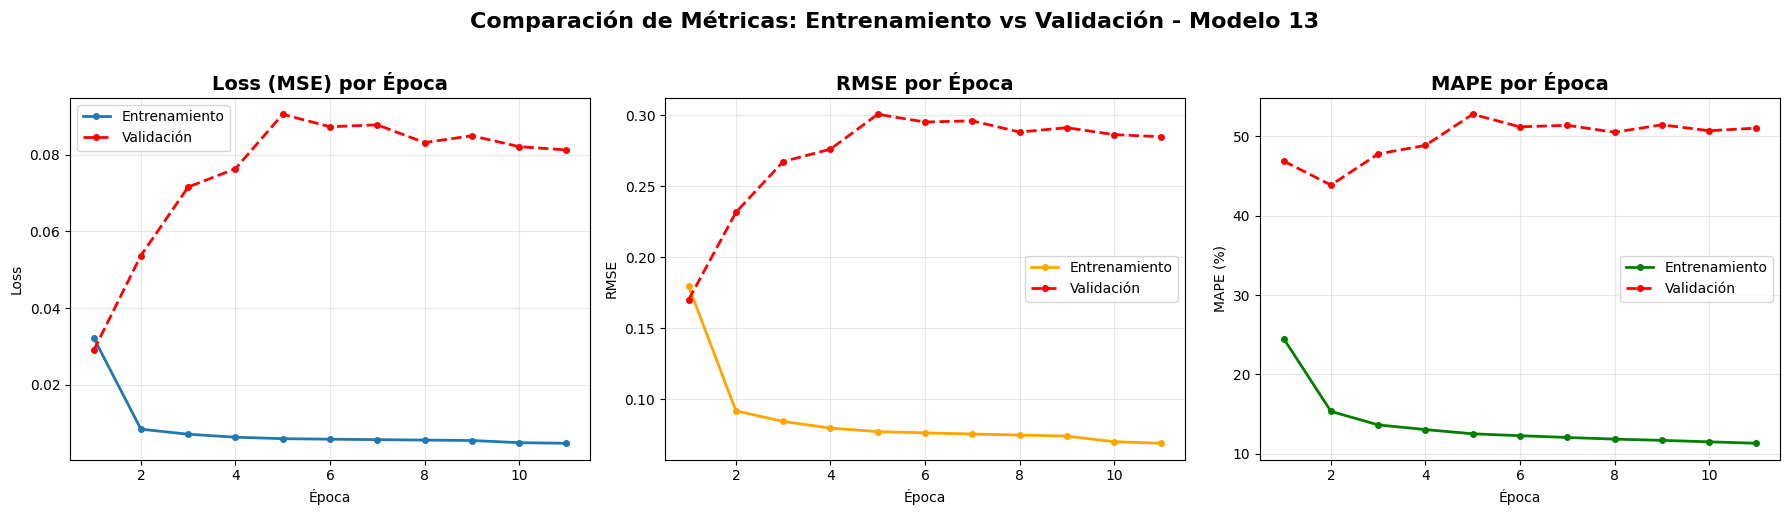

In [8]:
import matplotlib.pyplot as plt

# Extraer métricas del historial (entrenamiento y validación)
loss = history13.history['loss']
val_loss = history13.history['val_loss']

rmse = history13.history['root_mean_squared_error']
val_rmse = history13.history['val_root_mean_squared_error']

mape = history13.history['mean_absolute_percentage_error']
val_mape = history13.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 13',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

visualización de imagenes


Generando predicciones...
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


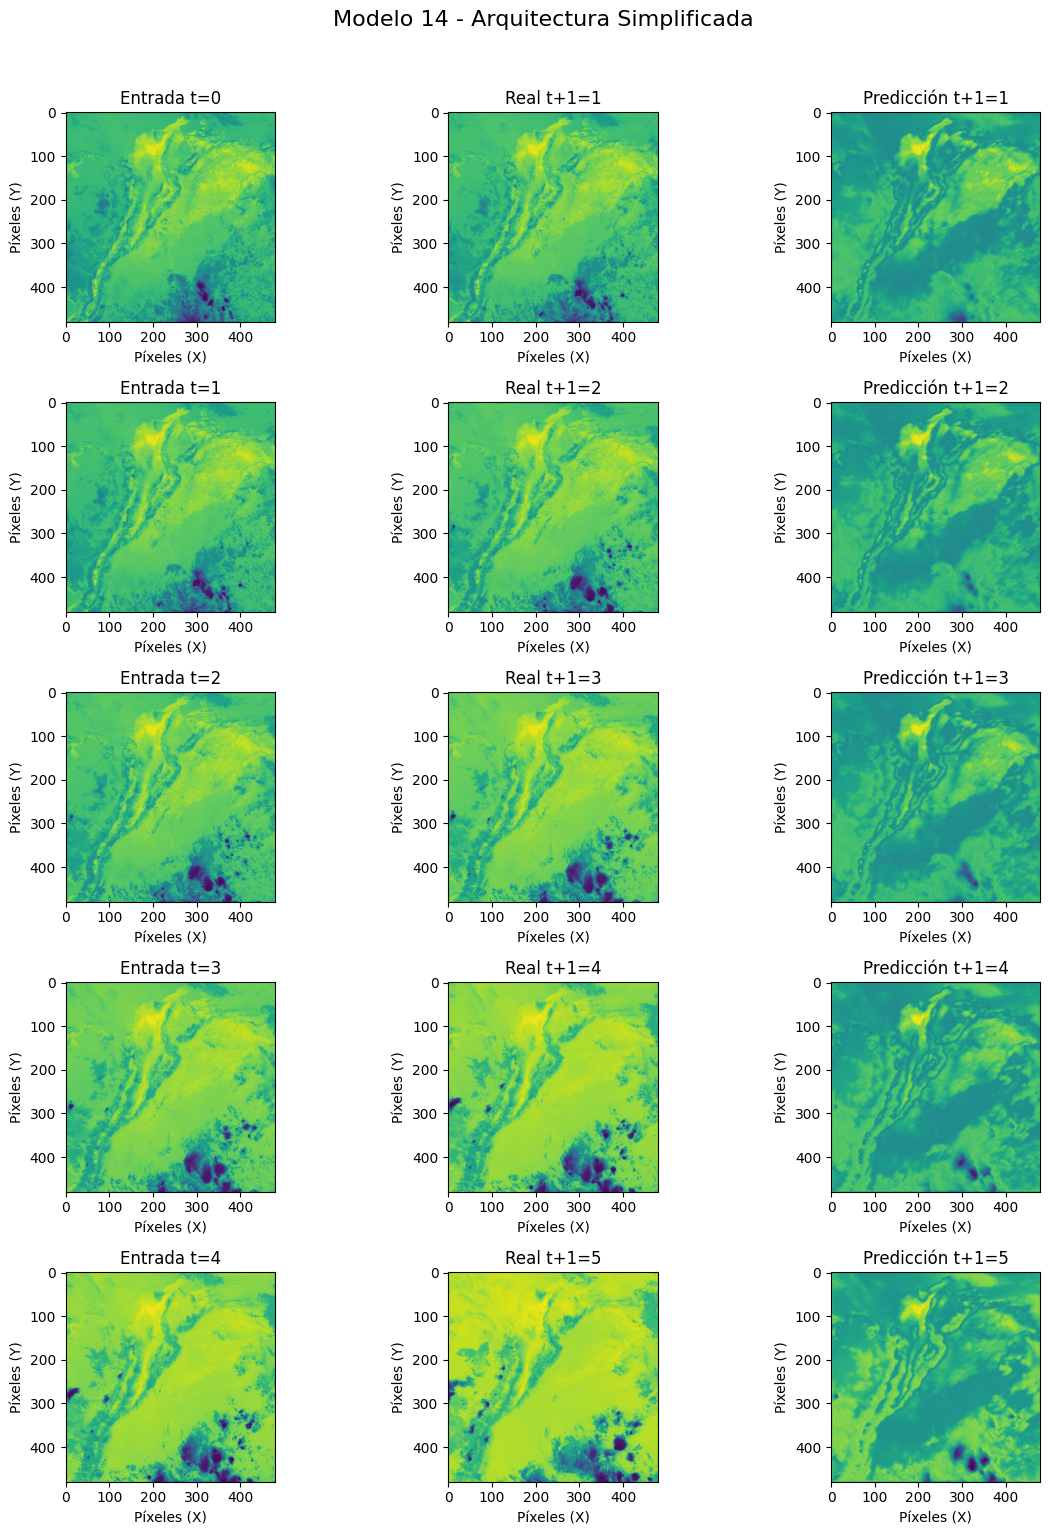

In [10]:
print("\nGenerando predicciones...")
y_pred = model13.predict(X_val[:10])

mostrar_resultados(
    X_val[:10, -1],
    y_val[:10],
    y_pred[:10],
    n=5,
    titulo_general="Modelo 14 - Arquitectura Simplificada",
    xlabel="Píxeles (X)",
    ylabel="Píxeles (Y)"
)

Prueba

In [16]:
# Directorio original y reducido
d_feb_1s = '/home/jhon/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = '/home/jhon/bandas/banda13/feb_01_07_1s_red'


# Llamar a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))

# Cargar imágenes de validación
file_list_test = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list_test]

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]

# Parámetro de secuencia temporal (debe ser el mismo que en entrenamiento)
timesteps = 3

# Construir secuencias para validación: X_seq_val (N, timesteps, H, W, C), y_seq_test (N, H, W, C)
X_base_test = np.array(images_test)[..., np.newaxis]  # (num_imgs_test, H, W, C)
y_base_test = X_base_test.copy()  # y_base_test igual a X_base_test

N_seq_test = X_base_test.shape[0] - timesteps
X_seq_test = np.array([X_base_test[i:i+timesteps] for i in range(N_seq_test)])  # (N_seq_test, timesteps, H, W, C)
y_seq_test= y_base_test[timesteps:]  # (N_seq_test, H, W, C)

print(f"Forma de X_seq_test: {X_seq_test.shape}")  # (N_seq_test, timesteps, H, W, C)
print(f"Forma de y_seq_test: {y_seq_test.shape}")  # (N_seq_test, H, W, C)

Procesando 167 imágenes para validación
Forma de X_seq_test: (164, 3, 480, 480, 1)
Forma de y_seq_test: (164, 480, 480, 1)


Metricas de testeo

In [17]:
# Ahora puedes evaluar el modelo
loss, rmse, mape = model13.evaluate(X_seq_test, y_seq_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0374 - mean_absolute_percentage_error: 62.6255 - root_mean_squared_error: 0.1933
Pérdida (MSE): 0.0374
RMSE: 0.1933
MAPE: 62.6255


6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


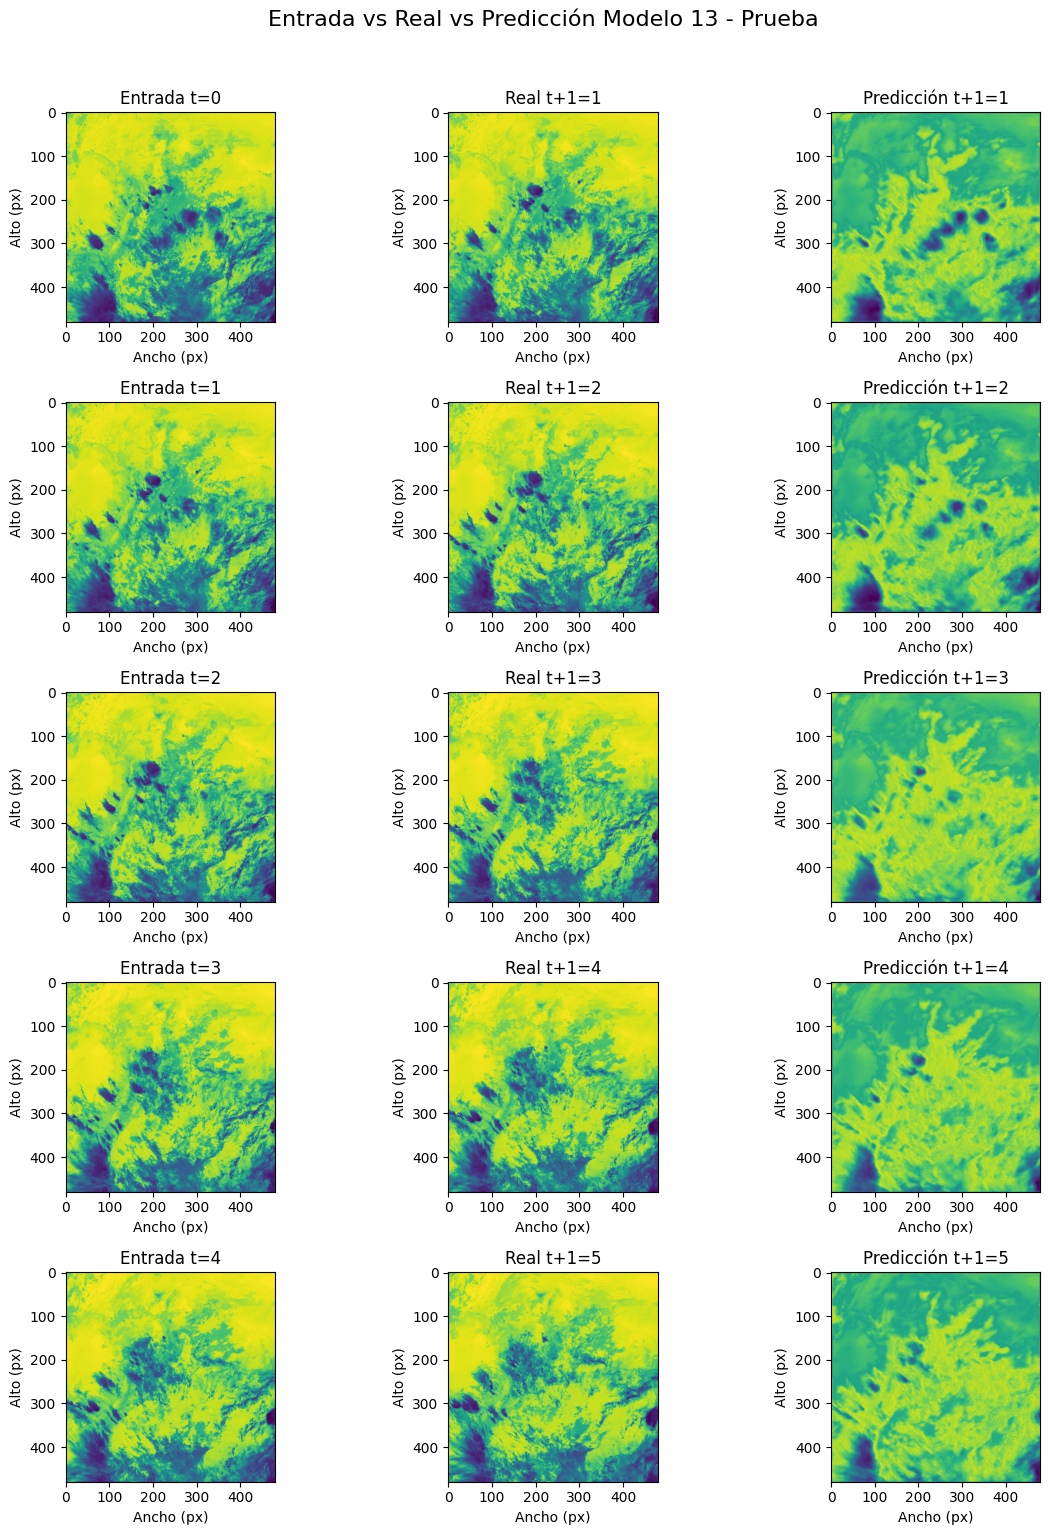

In [19]:
y_pred13_test = model13.predict(X_seq_test)  # Genera las predicciones usando X_seq_val
mostrar_resultados(
    X_seq_test[:, -1, :, :, :],  # Toma solo el último timestep de la secuencia de entrada
    y_seq_test,                   # Valores reales
    y_pred13_test,                # Predicciones
    n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 13 - Prueba",
    xlabel="Ancho (px)",
    ylabel="Alto (px)"
)